# Support Vector Classifier Strategy

In this notebook, we will be looking at the creation of a simple Support Vector Classifier (SVC) algorithm on S&P 500.

A Support Vector Classifier is a supervised learning algorithm designed for classification tasks. To build intuition, consider a basic example: suppose we want a model to distinguish between images of pens and pencils. We train the algorithm using a dataset of labeled images, allowing it to learn distinguishing features such as shape, length, or tip structure. Once trained, the model can classify new, unseen images based on the learned patterns.

![title](https://d2a032ejo53cab.cloudfront.net/Glossary/kGHBSe4T/SVMdiagram.png "backtest")

SVC operates by identifying an optimal decision boundary — known as a **hyperplane** — that separates data into distinct classes. The dimensionality of this hyperplane depends on the number of input features:
- With two features, the decision boundary is a line.
- With three features, it becomes a two-dimensional plane.
- In general, the hyperplane has *(number of features − 1)* dimensions.

The algorithm selects the hyperplane that maximizes the margin between classes, improving generalization to unseen data.

#### Step 1: Import the necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

#### Step 2: Download the S&P 500 Data

In [6]:
spy_ticker = 'SPY'
start_date = '2010-01-01'
end_date = '2023-12-31'

# Download SPY data
spy_data = yf.download(spy_ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


#### Step 3: Define the explanatory variables

Explanatory or independent variables are used to predict the value. The `X` is a dataset that holds the features that SVC algorithm will use as independent variables for prediction. The `X` consists of variables such as `Open - Close` and `High - Low`. These can be understood as indicators based on which the algorithm will predict tomorrow's trend. The choice of using `Open - Close` and `High - Low`as features is arbitrary. Feel free to add more features and see the performance.

In [7]:
# Create predictor variables
spy_data['Open-Close'] = spy_data.Open - spy_data.Close
spy_data['High-Low'] = spy_data.High - spy_data.Low

# Store all predictor variables in a variable X
X = spy_data[['Open-Close', 'High-Low']]
X.head()

Price,Open-Close,High-Low
Ticker,,
Date,,
2010-01-04,-0.720257,1.410503
2010-01-05,-0.277596,0.622724
2010-01-06,-0.142553,0.420149
2010-01-07,-0.517687,0.862810
2010-01-08,-0.510183,0.720257


#### Stpe 4: Define the target variable

Target variable is the outcome which the machine learning model will predict based on the explanatory variables. `y` is a target dataset storing the correct trading signal which the machine learning algorithm will try to predict. If tomorrow's price is greater than today's price then we will buy the S&P 500 index, else we will have no position in the S&P 500 index. We will store `1` for a buy signal and `0` for a no position in `y`.

We use `where()` function from NumPy to do this.

Syntax:
```python
import numpy as np
np.where(condition, value_if_true, value_if_false) 
```
Parameters: 

1. **Condition**: Condition to check
2. **value_if_true**: Value if the condition is satisfied 
3. **value_if_false**: Value If the condition is not satisfied

In [11]:
# Target variables
y = np.where(spy_data['Close'][spy_ticker].shift(-1) > spy_data['Close'][spy_ticker], 1, 0)
y

array([1, 1, 1, ..., 1, 0, 0])

#### Step 5: Split the data into train and test

We will split data into training and test datasets. This is done so that we can fit the model on the training data and test the performance on the test data.

1. First, 80% of data is used for training and remaining data for testing.
2. X_train and y_train are train datasets.
3. X_test and y_test are test datasets.

In [12]:
# Define the split percentage
split_percentage = 0.8
split = int(split_percentage*len(spy_data))

# Train data set
X_train = X[:split]
y_train = y[:split]

# Test data set
X_test = X[split:]
y_test = y[split:]

#### Step 6: Using the Support Vector Classifier (SVC)

We will use `SVC()` function from `sklearn.svm.SVC` library to create our classifier model using `fit()` method on the training dataset.

Syntax:
```python
from sklearn.svm import SVC
SVC().fit(X, y) 
```
Parameters:

1. **X**: Explanatory variables in the training set
2. **y**: Target variable in the training set

In [13]:
# Support vector classifier
cls = SVC().fit(X_train, y_train)

#### Stpe 7: Predict the Signals

We will use the `predict` method on the `cls` variable to predict the signals. We will pass `X_test` as the parameter to the `predict` method. 

In [14]:
y_predict = cls.predict(X_test)

#### Step 8: Classifier accuracy

We will compute the accuracy of the algorithm on the train and test data set by comparing the actual values of signal with the predicted values of signal. The function `accuracy_score()` will be used to calculate the accuracy.

Syntax:
```python
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_predicted) 
```
Parameters: 

1. **y_true**: Actual/correct labels

2. **y_predicted**: Predicted labels, as returned by the classifier

In [15]:
# train and test accuracy
accuracy_test = accuracy_score(y_test, y_predict)

print('Accuracy:{: .2f}%'.format(accuracy_test*100))

Accuracy: 51.63%


An accuracy of 50%+ in test data suggests that the classifier model is effective.

#### Step 9: Strategy implementation

**Predict signal**

We will predict the signal (buy or sell) using the `cls.predict()` function.

**Compute returns in test period**

We will predict the signals on the entire dataset `X`. And then we will compute strategy returns based on the predicted signal, and then save it in the column `cumulative_returns` and plot the cumulative returns. 

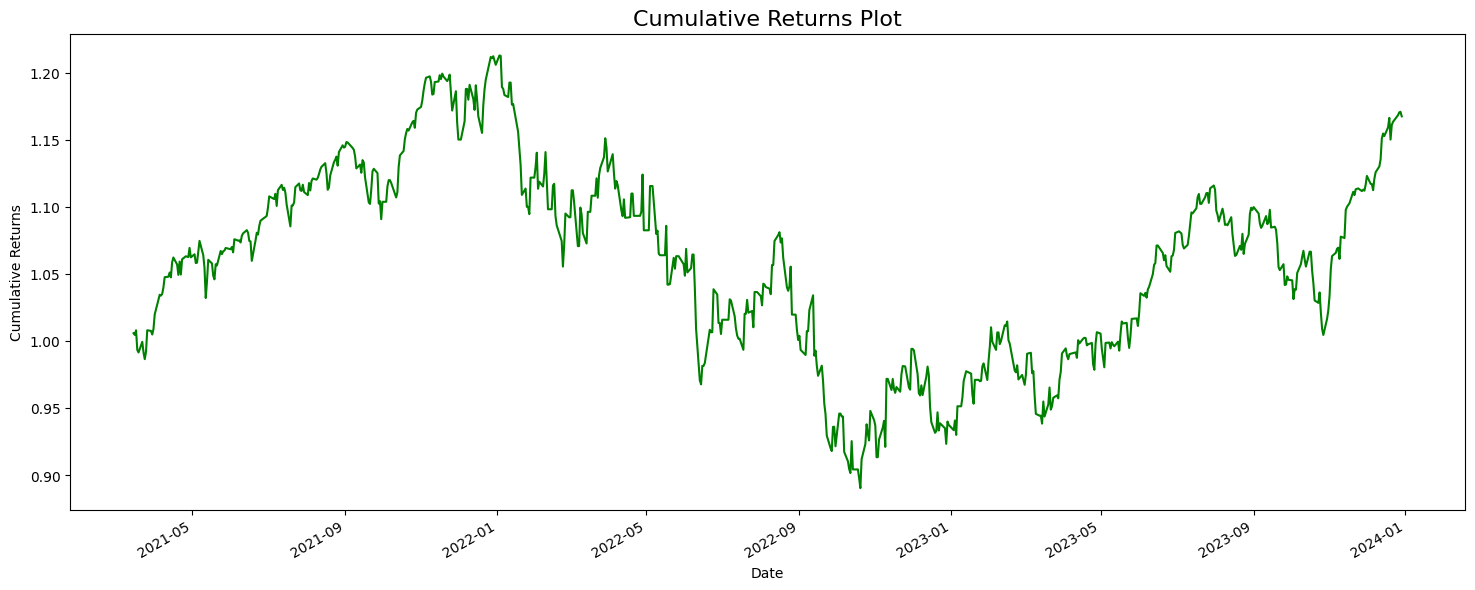

In [16]:
# Predicted Signal
spy_data['Predicted_Signal'] = cls.predict(X)

# Calculate daily returns
spy_data['Returns'] = spy_data.Close.pct_change()

# Calculate strategy returns
spy_data['Strategy_Returns'] = spy_data.Returns * spy_data.Predicted_Signal.shift(1)

# Calculate geometric returns
spy_data['cumulative_returns'] = (spy_data.Strategy_Returns.iloc[split:]+1).cumprod()

# Set the title and axis labels
plt.title("Cumulative Returns Plot", fontsize=16)
plt.ylabel("Cumulative Returns")
plt.xlabel("Date")

# Plot geometric returns
spy_data['cumulative_returns'].plot(figsize=(18, 7),color='g')

plt.show()

**Strategy's Performance Metrics on Test Data**

In [17]:
# Performance metrics on test set
test_data = spy_data.iloc[split:]

total_return = test_data['cumulative_returns'].iloc[-1] - 1
annualized_return = (test_data['cumulative_returns'].iloc[-1])**(252/len(test_data)) - 1
annualized_volatility = test_data['Strategy_Returns'].std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else 0

print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Total Return: 16.75%
Annualized Return: 5.69%
Annualized Volatility: 16.45%
Sharpe Ratio: 0.35


#### Step 10: Backtest with more individual stocks and benchmark the performance with an index

[*********************100%***********************]  1 of 1 completed


Accuracy for AAPL: 47.80%


[*********************100%***********************]  1 of 1 completed


Accuracy for MSFT: 50.64%


[*********************100%***********************]  1 of 1 completed


Accuracy for GOOGL: 49.93%


[*********************100%***********************]  1 of 1 completed


Accuracy for AMZN: 50.64%


[*********************100%***********************]  1 of 1 completed


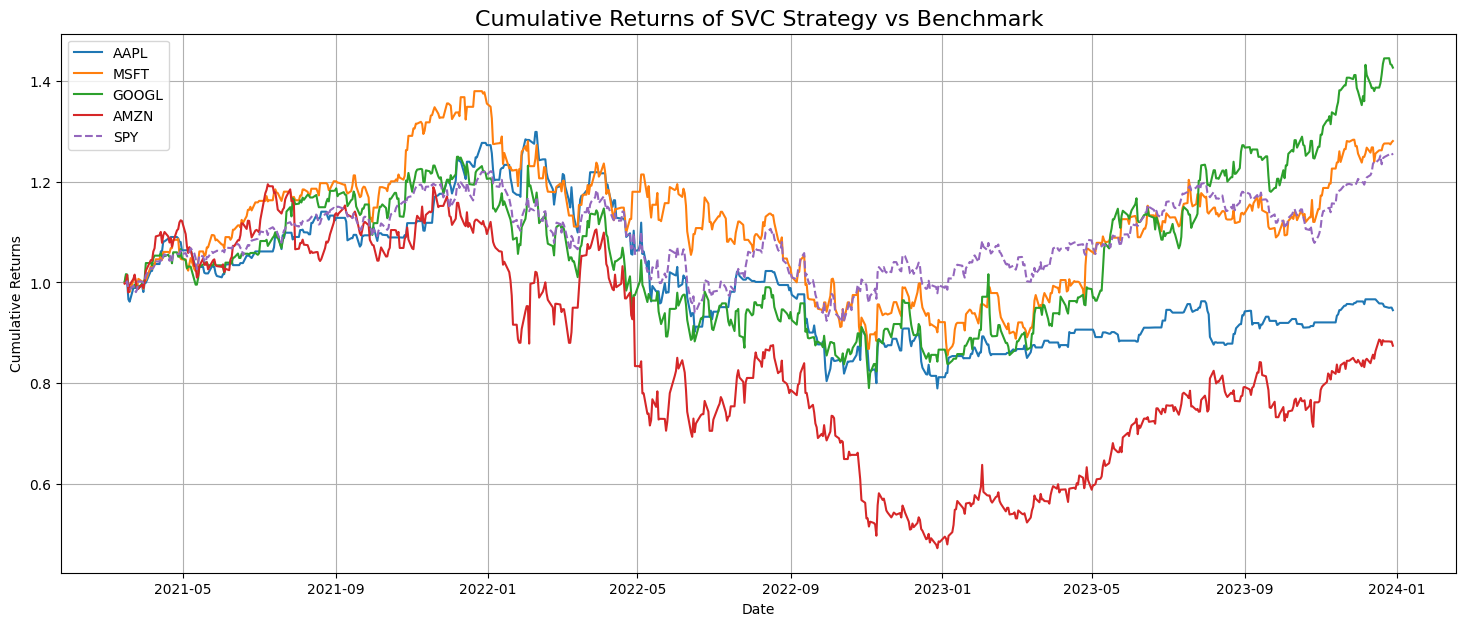

In [43]:
def svc_strategy(ticker, split_percentage, start_date, end_date):
  # Download data
  data = yf.download(ticker, start=start_date, end=end_date)

  # Create predictor variables
  data['Open-Close'] = data.Open - data.Close
  data['High-Low'] = data.High - data.Low

  # Store all predictor variables in a variable X
  X = data[['Open-Close', 'High-Low']]

  # Target variables
  y = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

  # Define the split percentage
  split = int(split_percentage*len(data))

  # Train and test datasets
  X_train, y_train = X[:split], y[:split]
  X_test, y_test = X[split:], y[split:]

  # Support vector classifier
  cls = SVC().fit(X_train, y_train)
  y_predict = cls.predict(X_test)

  # Accuracy
  accuracy_test = accuracy_score(y_test, y_predict)
  print(f'Accuracy for {ticker}: {accuracy_test*100:.2f}%')

  # Predicted Signal
  data['Predicted_Signal'] = cls.predict(X)

  # Calculate daily returns and strategy returns
  data['Returns'] = data.Close.pct_change()
  data['Strategy_Returns'] = data.Returns * data.Predicted_Signal.shift(1)

  # Calculate geometric returns
  data['cumulative_returns'] = (data.Strategy_Returns.iloc[split:]+1).cumprod()
  return data['cumulative_returns']

# Example usage
start_date = '2010-01-01'
end_date = '2023-12-31'
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
benchmark = 'SPY'
split_percentage = 0.8
cumulative_returns_dict = {}

for stock in stocks:
  cumulative_returns_dict[stock] = svc_strategy(stock, split_percentage, start_date, end_date)
  
benchmark_data = yf.download(benchmark, start=start_date, end=end_date)
benchmark_data_testing_period = benchmark_data.iloc[int(split_percentage*len(benchmark_data)):]
benchmark_cum_testing_period_returns = benchmark_data_testing_period['Close'].pct_change().add(1).cumprod()

# Performance metrics for benchmark and individual stocks
strategy_metrics = {}
for stock, cum_returns in cumulative_returns_dict.items():
  total_return = cum_returns.iloc[-1] - 1
  annualized_return = (cum_returns.iloc[-1])**(252/len(cum_returns)) - 1
  annualized_volatility = cum_returns.pct_change().std() * np.sqrt(252)
  sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else 0
  strategy_metrics[stock] = {
    'Total Return': total_return,
    'Annualized Return': annualized_return,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
  }

# Add benchmark metrics
benchmark_total_return = benchmark_cum_testing_period_returns.iloc[-1][benchmark] - 1
benchmark_annualized_return = (benchmark_cum_testing_period_returns.iloc[-1][benchmark])**(252/len(benchmark_cum_testing_period_returns)) - 1
benchmark_annualized_volatility = benchmark_cum_testing_period_returns[benchmark].pct_change().std() * np.sqrt(252)
benchmark_sharpe_ratio = benchmark_annualized_return / benchmark_annualized_volatility if benchmark_annualized_volatility != 0 else 0
strategy_metrics[benchmark] = {
  'Total Return': benchmark_total_return,
  'Annualized Return': benchmark_annualized_return,
  'Annualized Volatility': benchmark_annualized_volatility,
  'Sharpe Ratio': benchmark_sharpe_ratio
}

# Plotting on a single combined axis for the testing period
plt.figure(figsize=(18, 7))

for stock, cum_returns in cumulative_returns_dict.items():
  plt.plot(cum_returns.index, cum_returns.values, label=stock)

plt.plot(benchmark_cum_testing_period_returns.index, benchmark_cum_testing_period_returns.values, linestyle='--', label=benchmark)
plt.title("Cumulative Returns of SVC Strategy vs Benchmark", fontsize=16)
plt.ylabel("Cumulative Returns")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Put metrics in a DataFrame for better visualization
metrics_df = pd.DataFrame(strategy_metrics).T
metrics_df

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio
AAPL,-0.055195,-0.004054,0.216548,-0.018722
MSFT,0.281210,0.017889,0.248838,0.071889
GOOGL,0.427181,0.025777,0.282429,0.091270
AMZN,-0.125773,-0.009571,0.365864,-0.026161
SPY,0.253497,0.084111,0.177010,0.475177
